# PETaDex SignalP6 Pipeline

> **Author:** Angela Jiang  
> **Date Started:** 2026-07-01  
> **Date Finished:** 2026-07-31  
> **Input:** s3://\<input-bucket\>/signalp6_input/chunks/ (chunked
> PETaDex ORF FASTA)  
> **Output:** `signalp6_orf_predictions` (PostgreSQL table); raw SignalP
> archives at s3://\<output-bucket\>/signalp6_other/chunks/

------------------------------------------------------------------------

## 1. Objective

The goal of this pipeline is to predict signal peptides across every
PETaDex catalytic ORF using SignalP 6.0, and to load the results into a
compact, queryable PostgreSQL table. The corpus is split into FASTA
chunks, distributed across an AWS GPU Spot fleet using S3-backed atomic
job claiming, and the raw SignalP outputs are archived to S3 as the
authoritative provenance store. Only compact, parsed results are loaded
into PostgreSQL.

### 1.1. Place in the Project

Secreted enzymes are the ones most readily assayed and deployed against
plastic substrates, since the substrate is extracellular. Knowing which
PETaDex catalytic ORFs are predicted to carry a signal peptide — and
where the mature protein begins — lets us prioritize candidates for
expression and activity testing. It also lets downstream biochemical
analyses operate on a potentially more accurately mature starting point
for downstream processes like structural predictions or MSAs.

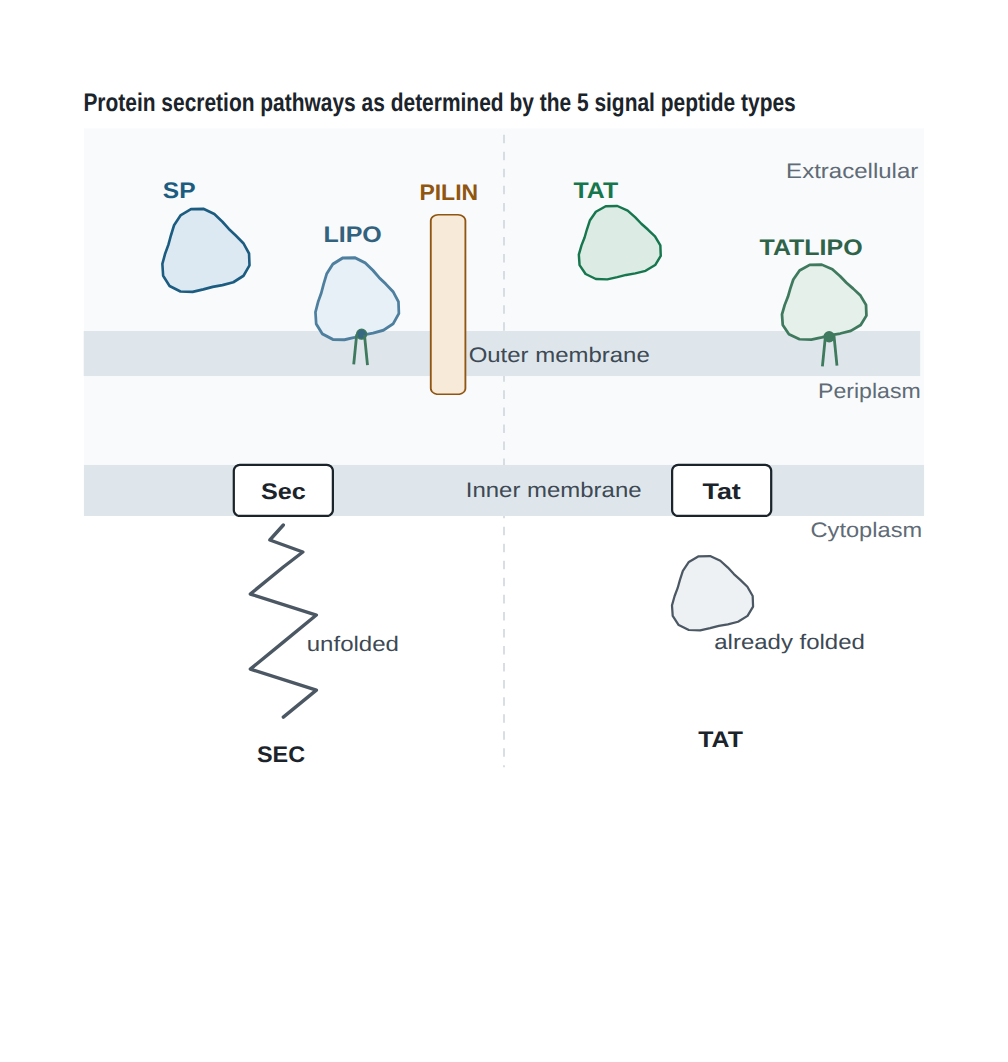

**Figure 1.** The five SignalP 6.0 signal classes and where each one puts its
protein. Sec exports an unfolded chain that folds after translocation; Tat
exports an already-folded protein. SP and TAT cargo is released; LIPO and
TATLIPO are cleaved at a lipobox cysteine and lipid-anchored to the membrane;
PILIN subunits polymerise into a surface pilus. The cleavage position stored in
`signalp6_orf_predictions` marks the boundary between the removed signal peptide
and the mature protein shown here.

## 2. Experiment

### 2.0. Install requirements

1.  SignalP 6.0 (Teufel et al. 2022, DTU Bioinformatics)
2.  Python 3.9+ with `boto3`
3.  AWS CLI v2 (fleet management only; workers use instance-role
    credentials)
4.  PostgreSQL client (`psql`) for loading

### 2.1. Tool and parameter selection

SignalP 6.0 is the first version based on a protein language model
(ESM-1b transformer), replacing the HMMER/LSTM architecture of SignalP
5, and unifies prediction across all signal peptide types in a single
model.

The invocation per chunk:

``` bash
signalp6 \
  --fastafile input.fa \
  --organism other \
  --model_dir <model_weights_directory> \
  --output_dir ./output
```

The two non-default options were selected for the following reasons:

-   `--organism other`: enables prediction of all six secretion classes
    (SP, LIPO, TAT, TATLIPO, PILIN, OTHER). PETaDex ORFs come from a
    phylogenetically diverse metagenomic corpus with no per-ORF organism
    annotation, so domain-specific modes (`euk`, `gram+`, `gram-`) would
    suppress secretion classes that may be present.
-   Model type `fast` (implicit default, not an explicit flag): a single
    forward pass rather than the `slow` ensemble. Selected because the
    corpus scale renders ensemble inference cost-prohibitive without a
    substantially larger GPU budget.

No additional flags are used. The default output produces all files
required for downstream parsing.

**Benchmark: `other` vs `euk` mode.** Run on 600 randomly sampled
PETaDex ORFs. Cleavage site predictions were identical in both modes;
the only difference was secretion class assignment, where `euk`
collapsed everything to SP while `other` correctly resolved a subset
into LIPO, TAT, and TATLIPO — confirming the mode choice above preserves
real signal.

**Benchmark: `fast` vs `slow` model.** Run on the same 600 ORFs. Only 1
of 600 differed in top predicted class; all others matched exactly on
both signal type and cleavage site.

**SignalP 6.0 vs SignalP 5.0.** SignalP 6.0 was chosen based on
published benchmarks demonstrating improved prediction accuracy across
signal peptide types (Teufel et al. 2022). SignalP 5.0 additionally does
not support TATLIPO or PILIN prediction, which is disqualifying for
complete annotation of a mixed-domain corpus.

### 2.2. Chunk the ORF FASTA corpus

Every PETaDex ORF record uses the following pipe-delimited header:

``` text
>{orf_id}|{genbank_accession}|{library_id}|{contig_id}|{orf_start}|{orf_end}|{orf_type}
```

`orf_id` is always the first field and always numeric. It is the sole
identifier extracted during SignalP parsing; all other header fields are
ignored.

The FASTA corpus is split into fixed-size work units using
`split_fasta_by_records.py` (Appendix A1):

``` bash
python split_fasta_by_records.py \
  --fasta petadex_orfs.fa \
  --outdir ./chunks \
  --records-per-chunk 10000 \
  --prefix chunk
```

`--records-per-chunk 10000` was chosen for the following reasons:

-   Keeps individual worker runtimes to roughly 10–20 minutes on GPU,
    limiting wasted progress on Spot interruption.
-   Remains large enough to avoid excessive S3 claim overhead relative
    to compute time per chunk.

The script streams the input file line by line (no full-file load into
memory) and writes a manifest TSV listing every produced chunk filename.
Chunks and the manifest are uploaded to an S3 input prefix before the
fleet starts.

### 2.3. Distribute work across the AWS GPU Spot fleet

Workers run on AWS GPU Spot instances managed by an Auto Scaling Group.
The following instance families are used in mixed capacity to maximise
Spot availability:

| Instance type                  | GPU                 | Notes                    |
|------------------------|------------------------|------------------------|
| `g4dn.xlarge` / `g4dn.2xlarge` | NVIDIA T4 (16 GB)   | Minimum tested GPU class |
| `g5.xlarge` / `g5.2xlarge`     | NVIDIA A10G (24 GB) |                          |
| `g6.xlarge`                    | NVIDIA L4 (24 GB)   |                          |

Workers operate entirely from instance local storage as scratch; no
result is held only in instance memory, all durable state is in S3:

``` text
s3://<input-bucket>/signalp6_input/chunks/     # FASTA work units
s3://<input-bucket>/signalp6_input/manifest/   # manifest TSV

s3://<output-bucket>/signalp6_other/chunks/    # result .tar.gz archives
s3://<output-bucket>/signalp6_other/done/      # done markers
s3://<output-bucket>/signalp6_other/claims/    # atomic claim markers
s3://<output-bucket>/signalp6_other/failed/    # failed markers
s3://<output-bucket>/signalp6_other/logs/      # per-chunk worker logs
```

**Atomic job claiming.** A claim object written to S3 (created only if
absent) prevents two workers from processing the same chunk, and lets
Spot-interrupted work be safely reclaimed by a replacement instance.

Worker loop per instance:

1.  Read the manifest; skip any chunk with an existing done or claim
    marker.
2.  Write a claim marker, download the chunk, and run SignalP6.
3.  Archive raw outputs into `.tar.gz` and upload it and the log to
    `chunks/`/`logs/`.
4.  On success: write a done marker. On failure: write a failed marker.
5.  Clean local scratch and continue.

### 2.4. Parse SignalP outputs and prepare upload parts

Each successful archive contains:

``` text
prediction_results.txt    # top class, per-class probabilities
region_output.gff3        # cleavage-site position and score
output.gff3
output.json
processed_entries.fasta
DONE
*.log
```

-   **`prediction_results.txt`** is the primary source for the predicted
    class and winning-class probability. Columns 3–8 give the six class
    probabilities in the fixed order
    `OTHER, SP, LIPO, TAT, TATLIPO, PILIN`; the winning-class
    probability is indexed by the predicted label.
-   **`region_output.gff3`** is the preferred source for the
    cleavage-site position and score. A known formatting issue in some
    `prediction_results.txt` files causes the `PILIN(Sec/SPIII)` column
    header to concatenate with the `CS Position` header, making the
    cleavage column unreliable there. The GFF3 structure is unambiguous
    and is used instead wherever available.

Archive members are matched by basename rather than by full path, so
both flat and nested internal archive layouts are handled transparently.

Archives are parsed by `parse_signalp_archives_to_upload.py` (Appendix
A3), which streams `.tar.gz` files directly from S3 without staging the
raw archives locally:

``` bash
python parse_signalp_archives_to_upload.py \
  --bucket <output-bucket> \
  --prefix signalp6_other/chunks/ \
  --outdir ./upload_parts \
  --rows-per-part 5000000 \
  --workers 16
```

-   `--workers 16`: number of concurrent S3 download and parse threads.
-   `--rows-per-part 5000000`: controls the size of each output part
    file; the corpus produces roughly 60 part files at this setting.

**Class normalisation.** Raw SignalP labels may appear in short (`SP`)
or long (`SP(Sec/SPI)`) form. All labels are normalised to their short
canonical form before integer encoding. `TATLIPO` is tested before `TAT`
and `LIPO` to avoid prefix collisions.

| Label              | Code |
|--------------------|------|
| OTHER              | 0    |
| SP (Sec/SPI)       | 1    |
| LIPO (Sec/SPII)    | 2    |
| TAT (Tat/SPI)      | 3    |
| TATLIPO (Tat/SPII) | 4    |
| PILIN (Sec/SPIII)  | 5    |

**orf_id extraction:** the leading pipe-delimited field established in
2.2, cast to integer:

``` python
orf_id = int(seq_id.split("|", 1)[0])
```

**Output format.** Each part file is a gzip-compressed tab-separated
file with a header row and `\N` as the null token:

``` text
orf_id    top_signal    signal_prob    cleavage_pos    cleavage_prob
```

`cleavage_pos` and `cleavage_prob` are `\N` for all `top_signal = 0`
(OTHER) rows; these rows are filtered out before loading (reasoning in
2.5).

### 2.5. Create the PostgreSQL schema

The table stores only ORFs with a predicted signal peptide (`top_signal`
1–5); OTHER-classified ORFs are already mature proteins with no signal
sequence to annotate, so they’re excluded rather than stored with null
cleavage fields. Full `CREATE TABLE` statement, constraints, and column
comments: Appendix A5.

Design rationale — tool, version, and run-mode constants live in the
table comment rather than per-row columns, since repeating them across
hundreds of millions of rows would add billions of bytes for no benefit:

| Column          | Type            | Rationale                                                                                                                                                             |
|------------------------|------------------------|------------------------|
| `orf_id`        | `BIGINT`        | orf_ids will exceed 2.1 billion as PETaDex grows; INTEGER would risk overflow.                                                                                        |
| `top_signal`    | `SMALLINT`      | Six possible values; 2 bytes vs 4 for INTEGER (\~600 MB saved at scale). Integer encoding avoids per-row TEXT storage (\~1.8 GB saved vs storing label strings).      |
| `signal_prob`   | `REAL`          | 4-byte float; 7 significant figures is sufficient for probability values. DOUBLE PRECISION saves no meaningful accuracy (\~1.2 GB saved).                             |
| `cleavage_pos`  | `SMALLINT NULL` | Signal peptides are biologically bounded well below 32,767 residues. NULL only in rare SignalP edge cases where a positive label is returned without a cleavage site. |
| `cleavage_prob` | `REAL NULL`     | Same rationale as `signal_prob`. NULL when GFF3 score is absent.                                                                                                      |

**Foreign key** is declared `NOT VALID` (created without a table scan;
rows load without row-level FK validation) and validated once after the
bulk load completes.

**Index:** a single full index on `top_signal`. The table already holds
only positive hits, so there’s no OTHER population to exclude with a
partial index; `top_signal` is the primary query filter since it encodes
secretion route. `orf_id` is automatically indexed as the primary key.
The index is built after the bulk load, not before.

### 2.6. Bulk load into PostgreSQL

``` bash
psql "host=<HOST> port=5432 dbname=petadex user=<USER> sslmode=require" \
  -c "\copy signalp6_orf_predictions (orf_id, top_signal, signal_prob, cleavage_pos, cleavage_prob)
      FROM PROGRAM 'gunzip -c signalp_upload_part_000000.tsv.gz'
      WITH (FORMAT csv, HEADER true, DELIMITER E'\t', NULL '\N');"
```

Repeat for each part file. Indexes and FK validation (2.5) are applied
after all parts are loaded.

## 3. Results and Discussion

All counts below are whole-corpus and exact — every ORF was screened, and no
figure in this section extrapolates from a sample. Denominators come from
`orf_origins` (307,155,746 ORFs), since `signalp6_orf_predictions` stores
positive hits only (2.5).

### 3.1. Corpus-wide secretion rate

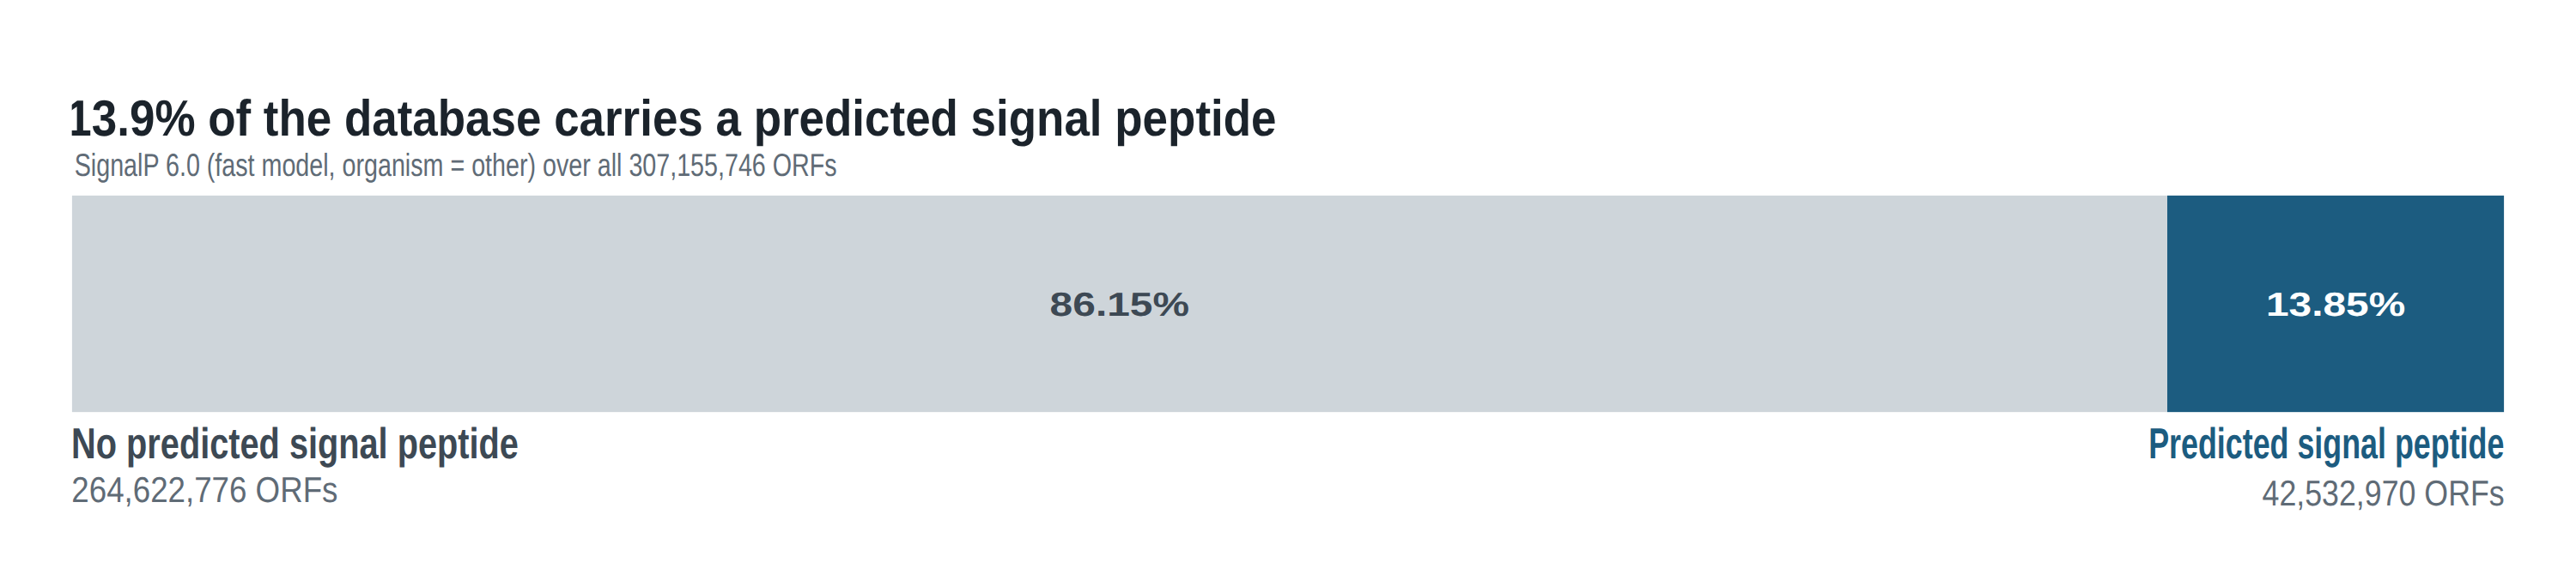

**Figure 2.** Share of the catalytic ORF database with a predicted signal
peptide.

SignalP 6.0 returned a positive signal-peptide call for **42,532,970 of
307,155,746 ORFs (13.85%)**; the remaining 264,622,776 (86.15%) were classified
OTHER and are not stored (2.5).

Roughly one ORF in seven is predicted to be exported. That is high enough to
confirm the catalytic corpus is not dominated by cytoplasmic enzymes, which
matters because plastic substrates are extracellular — a PET-degrading candidate
that never leaves the cell is not a usable starting point without re-engineering
its localization. It is also, on its own, a useless filter: 42.5M candidates is
far too many to triage by hand, so the value of this table is as a *join target*
for the narrower filters in 3.2–3.4 rather than as a shortlist.

Two caveats attach to the headline number and to everything downstream of it.
First, these are predictions, not observations; no candidate in this set has
been shown experimentally to be secreted. Second, PETaDex ORFs are metagenomic
translations of assembled contigs, and an ORF whose 5' end was truncated during
assembly has lost the very N-terminal region SignalP reads. Truncation can
therefore only *deflate* this rate, never inflate it, so 13.85% is best read as
a lower bound.

### 3.2. Signal class composition and cleavage position

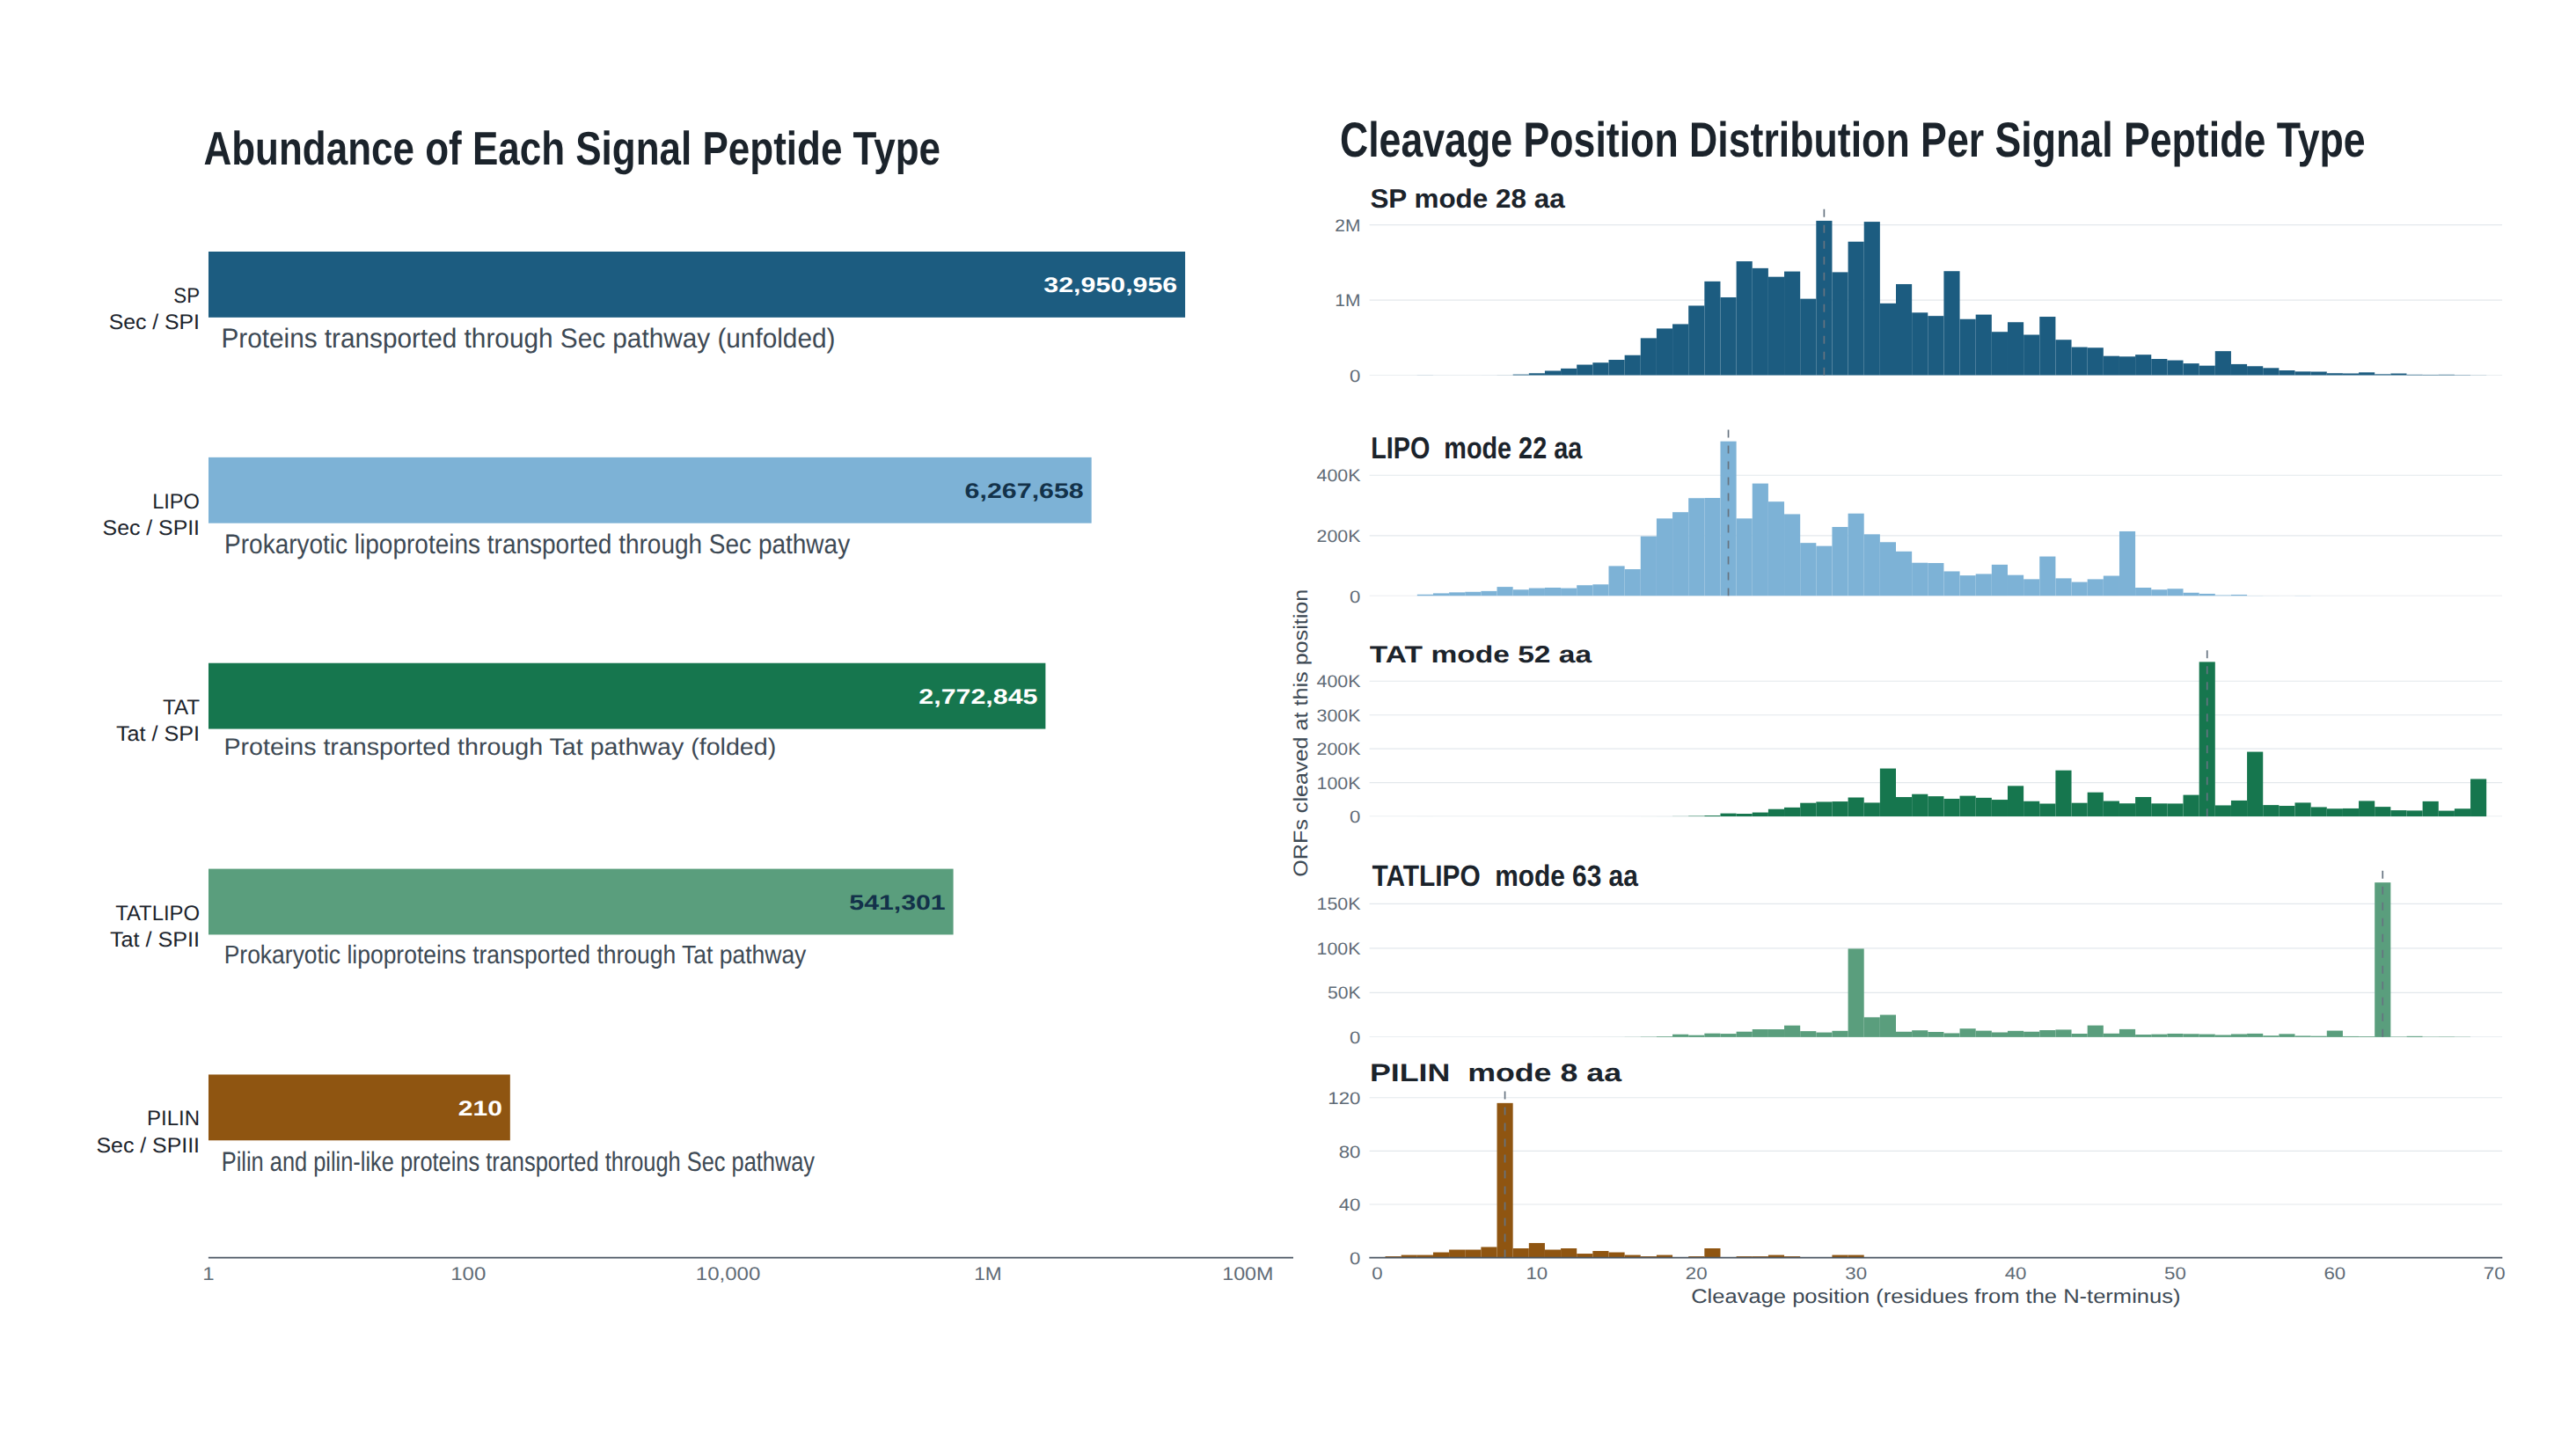

**Figure 3.** Left: abundance of each of the five signal classes, log axis.
Right: cleavage-position distribution per class, each panel on its own y scale.

**Composition.** The five classes are distributed across five orders of
magnitude, which is why the left panel needs a log axis:

| Class | Route | ORFs | % of positives |
|---|---|---:|---:|
| SP | Sec / SPI | 32,950,956 | 77.47% |
| LIPO | Sec / SPII | 6,267,658 | 14.74% |
| TAT | Tat / SPI | 2,772,845 | 6.52% |
| TATLIPO | Tat / SPII | 541,301 | 1.27% |
| PILIN | Sec / SPIII | 210 | 0.0005% |

Grouped by translocon, **39,218,824 (92.21%)** of positives route through Sec
and **3,314,146 (7.79%)** through Tat. The Sec/Tat split is the operationally
important one: Tat exports already-folded proteins (Figure 1), so a Tat-targeted
candidate must fold in the cytoplasm before export. For heterologous expression
that is a meaningfully different problem from a Sec candidate, which crosses
unfolded and folds outside. At 3.3M ORFs the Tat set is large enough to be worth
treating as its own cohort rather than a rounding error.

PILIN's 210 hits deserve explicit caution. It is the only class small enough
that any statement about it is anecdotal, and it recurs as an outlier in 3.3 for
the same reason.

**Cleavage position.** Modal cut sites are SP 28 aa, LIPO 22 aa, TAT 52 aa,
TATLIPO 63 aa, PILIN 8 aa. The two Tat classes carry markedly longer signal
peptides than their Sec counterparts, consistent with the twin-arginine motif
adding an extended n-region ahead of the hydrophobic core.

Each panel is scaled to its own counts, not to a shared maximum. This is
deliberate and worth stating: peak heights range from 2,054,424 ORFs (SP at
position 28) to 116 (PILIN at position 8), so a shared axis would render four of
the five distributions invisible, and a peak-normalized axis — which an earlier
draft of this figure used — would imply the five distributions are comparable in
mass when they differ by five orders of magnitude. Heights are comparable within
a panel and never between panels.

**TATLIPO is bimodal and should not be summarized by its mode.** Its modal
position is 63 aa, but its median is 41 aa, with the mode sitting at the extreme
right edge of the distribution. Quoting "TATLIPO cleaves at 63 aa" would
misdescribe most of the class. This is visible only because the panel carries a
real count axis.

**Denominators differ slightly from the left panel.** The histograms are drawn
over ORFs that have a cleavage position — **4,466 fewer** than the positive-hit
counts (3,754 SP and 712 TAT returned a positive class label with no usable
cleavage site, the `cleavage_pos IS NULL` edge case documented in 2.5). At 0.010%
of positives this does not move any distribution, but the two panels are not
drawn over identical row sets.

**Methodological note.** These distributions use exact integer `cleavage_pos`
values. An earlier binned export built with `width_bucket` carried a
floating-point artifact that merged bins 12, 23, 45 and 64 into the preceding
bin on every class, producing spurious structure. Re-querying with exact
positions removed those artifacts and confirmed that the genuine features — the
TAT peak near 52 aa and the TATLIPO peak near 63 aa — survive; they are real,
not binning residue.

**Downstream use.** `cleavage_pos` defines where the mature protein begins, and
is consumed directly by the biochemical-properties pipeline
(`orf_biochemical_properties`) to compute mature-sequence molecular weight, pI,
GRAVY, instability index and aromaticity alongside the full-ORF values. Removing
a signal peptide measurably shifts those properties in the expected direction —
lower GRAVY and lower pI, since the signal peptide contributes a hydrophobic
core and a positively charged n-region — so this column is what makes
secreted-candidate triage operate on the molecule that is actually assayed
rather than on the translated ORF.

### 3.3. Signal type is conserved within sequence clusters

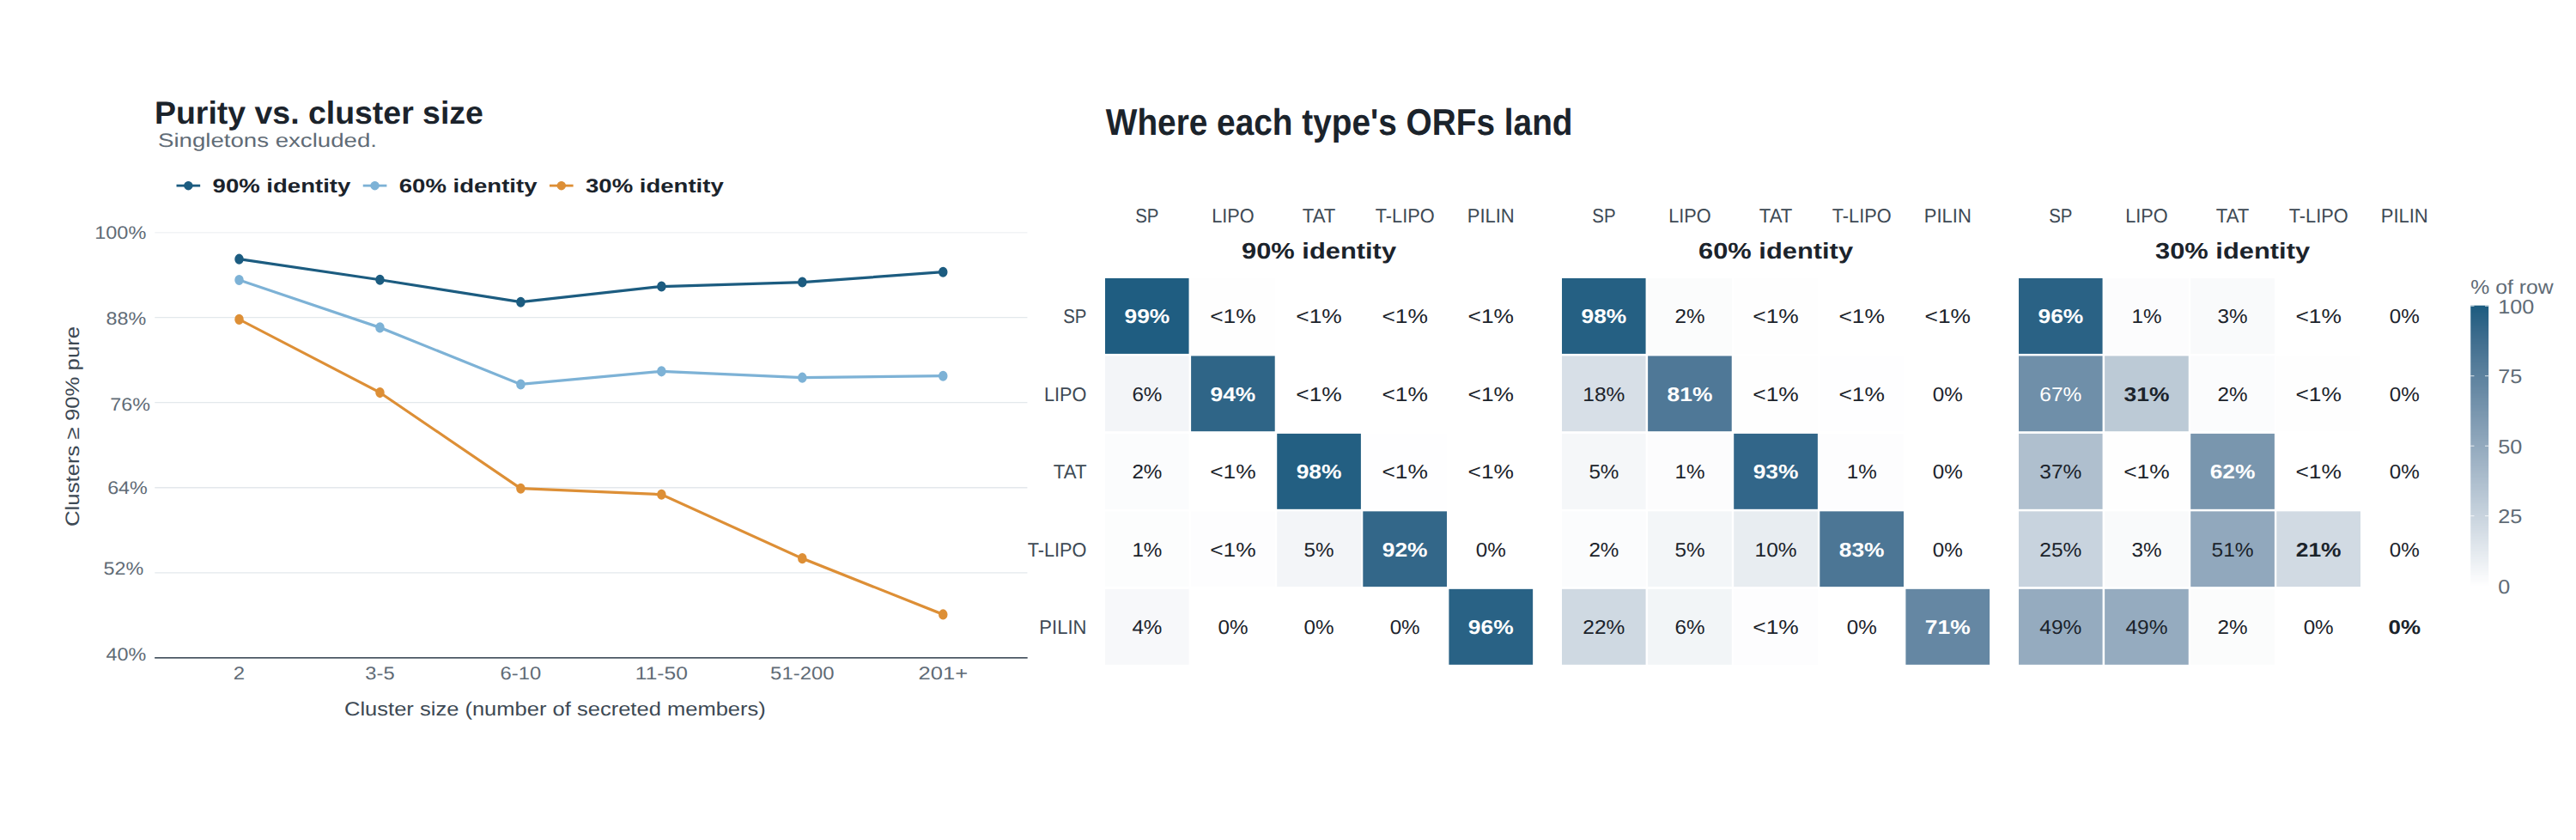

**Figure 4.** Left: share of clusters at least 90% pure by signal type, against
cluster size, at three identity thresholds. Right: row-normalized destination of
each type's ORFs. Singleton clusters excluded throughout (their purity is
trivially 1).

Joining `signalp6_orf_predictions` to `petadex_clustering` on `orf_id` asks
whether signal type tracks sequence similarity. It does, and the degree to which
it stops doing so is itself informative.

**Purity against cluster size.** Share of clusters that are ≥90% pure:

| Cluster size | 90% identity | 60% identity | 30% identity |
|---|---:|---:|---:|
| 2 | 96.2% | 93.3% | 87.7% |
| 3–5 | 93.3% | 86.6% | 77.4% |
| 6–10 | 90.2% | 78.6% | 63.9% |
| 11–50 | 92.4% | 80.4% | 63.0% |
| 51–200 | 93.0% | 79.5% | 54.0% |
| 201+ | 94.4% | 79.8% | 46.1% |

(non-singleton clusters: 1,442,826 at 90pid, 317,677 at 60pid, 8,791 at 30pid)

At 90% identity purity is **flat at 90–96% regardless of cluster size** — a
1,000-member enzyme cluster is as type-pure as a 2-member one. At 60% identity
it drops to a plateau near 79–80% and likewise stops depending on size. Only at
30% identity does size matter: purity falls monotonically from 87.7% to 46.1% as
superfamilies grow.

That the size dependence appears *only* at the superfamily level is the
substantive result. If signal type were assigned noisily, larger clusters would
dilute at every threshold. Instead, type is essentially fixed within an enzyme
family and erodes only once clusters are loose enough to span different
secretion strategies.

**Where each type's ORFs land.** Row-normalized diagonal (the share of a type's
ORFs sitting in a cluster whose majority is that same type):

| Type | 90% id | 60% id | 30% id |
|---|---:|---:|---:|
| SP | 99.2% | 97.5% | 95.7% |
| LIPO | 94.2% | 81.2% | 30.9% |
| TAT | 98.1% | 92.9% | 62.3% |
| TATLIPO | 92.5% | 82.5% | 21.0% |
| PILIN | 96.2% | 71.4% | 0.0% |

Two patterns stand out at 30% identity. **LIPO inverts**: only 30.9% of LIPO
ORFs sit in a LIPO-majority superfamily while 66.8% sit in an SP-majority one.
**TATLIPO behaves similarly**, with 50.9% landing in TAT-majority superfamilies
against 21.0% in its own. Both are consistent with the lipobox being a local
C-terminal feature of the signal peptide rather than a property of the mature
fold: at superfamily distance a lipoprotein and its non-lipidated relative are
the same enzyme family.

**PILIN reaches exactly 0% on its own diagonal at 30% identity**, splitting
almost evenly between SP-majority (49.0%) and LIPO-majority (49.0%)
superfamilies. With n = 210 this is a description of a handful of sequences, not
a population result, and should not be presented as a finding about pilins in
general.

**An important caveat on "majority type."** SP accounts for 77% of all positive
hits, so in any mixed cluster SP is the most likely majority by abundance alone.
Part of the 30pid decline is therefore compositional rather than evolutionary —
the metric asks which type dominates, and one type dominates the corpus. The
LIPO and TATLIPO inversions are not explained away by this (both retain high
diagonals at 60% identity, where the same abundance skew applies), but the
headline "purity falls at 30% identity" should not be read as a pure measure of
signal-type divergence.

**Open QC question, deferred.** Reviewer feedback raised a related point: within
a 90% identity cluster, why do any members disagree on signal type at all? One
plausible explanation is N-terminal truncation during assembly — a fragmentary
ORF loses its signal peptide and is called OTHER while its full-length cluster
neighbours are called SP. If so, the 3–10% impurity at 90% identity is partly an
assembly-quality signal rather than biology, and could be turned into a
truncation detector. This has been deferred to a separate investigation; it is
noted here because it bears on the lower-bound reading of the 13.85% headline
rate in 3.1.

### 3.4. Secretion rate by catalytic fold family

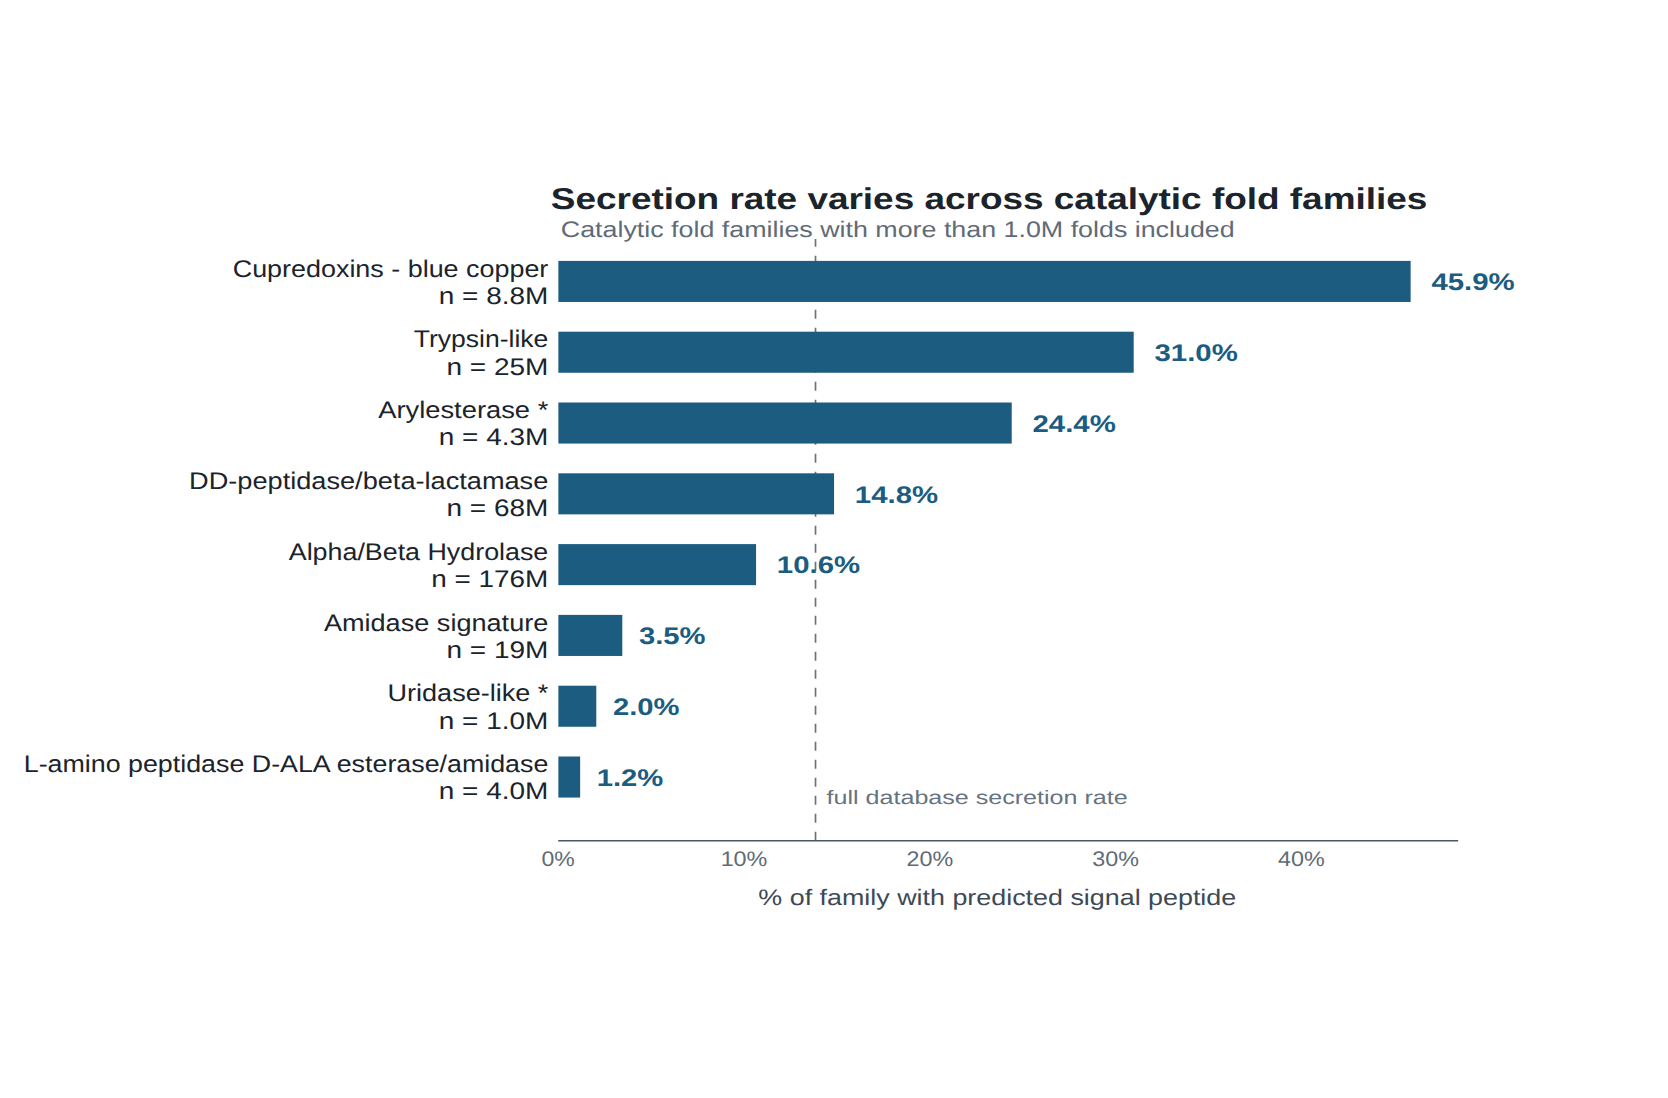

**Figure 5.** Predicted secretion rate per catalytic fold family. Dashed line =
the 13.85% database-wide rate.

`petadex_catalytic_domains` is keyed `PRIMARY KEY (orf_id)`, so every ORF carries
exactly one assigned catalytic domain and the families below are mutually
exclusive — no ORF is counted in two bars. Note that the table records one
representative domain occurrence per ORF (with `domain_start` / `domain_end`
coordinates), not an exhaustive enumeration of every catalytic domain an ORF
contains; "family" below means each ORF's assigned catalytic domain.

| Fold family | ORFs | Secreted | Rate |
|---|---:|---:|---:|
| Cupredoxins — blue copper | 8,766,398 | 4,021,975 | 45.9% |
| Trypsin-like | 25,173,131 | 7,797,145 | 31.0% |
| Arylesterase * | 4,342,535 | 1,059,973 | 24.4% |
| DD-peptidase / beta-lactamase | 68,249,861 | 10,133,439 | 14.8% |
| Alpha/Beta Hydrolase | 175,533,373 | 18,692,466 | 10.6% |
| Amidase signature | 19,451,440 | 671,082 | 3.5% |
| Uridase-like * | 1,012,895 | 20,755 | 2.0% |
| L-amino peptidase / D-ALA esterase-amidase | 4,020,046 | 47,480 | 1.2% |

\* family identified from its HMM; no CATH code assigned yet.

Secretion rate spans **38-fold** across fold families, from 45.9% to 1.2% —
by far the strongest stratification of any variable examined. Four families sit
above the database rate and four below. The ordering is biologically coherent:
cupredoxins are largely periplasmic and extracellular copper proteins, and
trypsin-like folds include the secreted proteases, while the amidase-signature
and peptidase families at the bottom are predominantly cytoplasmic.

**Rate and absolute yield point in opposite directions, and this matters for
PETaDex.** Alpha/Beta Hydrolase — the fold that includes the known PET
hydrolases — sits *below* the database rate at 10.6%. But it is also 57% of the
entire corpus, so in absolute terms it supplies **18,692,466 secreted ORFs, 44%
of all secreted ORFs in the figure**, more than any other family. Together the
three largest families (Alpha/Beta Hydrolase, DD-peptidase/beta-lactamase,
Trypsin-like) account for 86% of secreted ORFs despite none having a
top-two rate. Ranking candidate families by secretion *rate* would therefore
deprioritize exactly the fold PETaDex exists to search. Rate is the right
statistic for asking whether a fold tends to be exported; absolute count is the
right one for asking where the candidates actually are.

**Coverage and exclusions.** The figure covers 306,549,679 ORFs (99.803% of the
corpus) and 42,444,315 positive hits (99.792%). Two rows from the underlying
query are excluded: a shared placeholder CATH code merging two unrelated
families (oxygenase-like and cytochrome c-like, n = 605,307 combined), whose
pooled rate would not be a property of either family; and cyclase-like
(n = 760), too small to support a rate against families of 10⁶–10⁸. The full
ten-row query reconciles exactly to 307,155,746 ORFs and 42,532,970 positives,
which also independently validates the `pazy_hmm_id` suffix normalization the
`petadex_catalytic_domains` → `pazy_hmms` → `component_cath_dictionary` join
required (the source tables were generated on different dates, and a direct ID
match returns zero rows).

### 3.5. Limitations

**These are predictions.** No candidate in the 42.5M positive set has been shown
experimentally to be secreted. SignalP 6.0 was run in `fast` mode; benchmarking
(2.1) found 1 of 600 sampled ORFs differed in top class between `fast` and
`slow`, with identical cleavage sites, so mode choice is not a material source
of error at this scale — but model error itself is unquantified here.

**Fragmentary ORFs bias the rate downward.** Metagenomic assembly can truncate
an ORF's 5' end, removing the region SignalP reads. Such an ORF is called OTHER
regardless of what the full-length protein would do, so 13.85% is a lower bound.
The cluster-impurity signal discussed in 3.3 may offer a way to quantify this.

**No taxonomic stratification is reported.** Secretion rate by domain of life
was examined and excluded. The only classification available corpus-wide labels
an ORF by its *source library's* declared organism rather than by its own
sequence, and full domain-of-life resolution exists only for a curated NCBI
subset covering under 0.02% of ORFs — too small, and too biased toward
well-characterized proteins, to support domain-level rate comparisons. For the
record, the one whole-corpus split that is available shows no effect: 13.64%
among ORFs from libraries with eukaryote-resolving metadata (n = 93.3M) versus
13.94% among the remainder (n = 213.9M), a 0.29 percentage-point difference.
This is a label-provenance check, not a biological comparison.

**PILIN is too small to generalize from.** At n = 210 every PILIN statement in
3.2 and 3.3 describes a specific handful of sequences.

**Cluster majority is abundance-sensitive.** See the caveat in 3.3: SP's 77%
share of positives means it is the most likely majority type in any mixed
cluster by construction.

------------------------------------------------------------------------

## Appendix: Pipeline Scripts

### A1. `split_fasta_by_records.py`

Splits a FASTA file into fixed-size chunk files and writes a manifest
TSV.

``` python
#!/usr/bin/env python3
"""Split a FASTA file into N-record chunks.

Works as a simple local splitter before uploading chunks to S3.
"""
import argparse
from pathlib import Path


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--fasta", required=True)
    ap.add_argument("--outdir", required=True)
    ap.add_argument("--records-per-chunk", type=int, default=10000)
    ap.add_argument("--prefix", default="chunk")
    args = ap.parse_args()

    outdir = Path(args.outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    chunk_idx = -1
    record_idx = 0
    out = None
    manifest = []

    def open_chunk(i):
        path = outdir / f"{args.prefix}_{i:08d}.fa"
        manifest.append(path.name)
        return path.open("w"), path

    with open(args.fasta) as f:
        for line in f:
            if line.startswith(">"):
                if record_idx % args.records_per_chunk == 0:
                    if out:
                        out.close()
                    chunk_idx += 1
                    out, current_path = open_chunk(chunk_idx)
                record_idx += 1
            if out is None:
                raise RuntimeError("Input did not start with FASTA header")
            out.write(line)
    if out:
        out.close()

    manifest_path = outdir / "manifest.tsv"
    with manifest_path.open("w") as m:
        m.write("chunk_file\n")
        for name in manifest:
            m.write(name + "\n")

    print(f"Records: {record_idx}")
    print(f"Chunks: {len(manifest)}")
    print(f"Manifest: {manifest_path}")

if __name__ == "__main__":
    main()
```

------------------------------------------------------------------------

### A2. `audit_signalp_s3_archives.py`

Lists all `.tar.gz` archives under an S3 prefix and classifies them by
naming pattern.

``` python
#!/usr/bin/env python3
"""Audit SignalP S3 result archives.

Lists .tar.gz archives under an S3 prefix and classifies old 50k parent chunks
versus newer 10k part chunks by filename pattern.
"""
import argparse, re, csv
from collections import Counter
import boto3

TENK_RE = re.compile(r"chunk_\d{6}_part_\d{3}\.tar\.gz$")
OLD_RE  = re.compile(r"signalp_other_chunk_\d{6}\.tar\.gz$")


def iter_keys(s3, bucket, prefix):
    token = None
    while True:
        kwargs = dict(Bucket=bucket, Prefix=prefix)
        if token:
            kwargs["ContinuationToken"] = token
        resp = s3.list_objects_v2(**kwargs)
        for obj in resp.get("Contents", []):
            yield obj
        if not resp.get("IsTruncated"):
            break
        token = resp.get("NextContinuationToken")


def classify(key):
    name = key.rsplit("/", 1)[-1]
    if TENK_RE.search(name):   return "10k_part"
    if OLD_RE.search(name):    return "50k_parent_old"
    if name.endswith(".tar.gz"): return "tar_gz_other"
    return "other"


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--bucket",  required=True)
    ap.add_argument("--prefix",  required=True)
    ap.add_argument("--out",     default="archive_audit.tsv")
    ap.add_argument("--region",  default="us-east-1")
    args = ap.parse_args()

    s3     = boto3.client("s3", region_name=args.region)
    counts = Counter()
    rows   = []
    for obj in iter_keys(s3, args.bucket, args.prefix):
        key = obj["Key"]
        cls = classify(key)
        counts[cls] += 1
        if key.endswith(".tar.gz"):
            rows.append([key, cls, obj.get("Size", 0), obj.get("LastModified", "")])

    with open(args.out, "w", newline="") as f:
        w = csv.writer(f, delimiter="\t")
        w.writerow(["key", "archive_style", "size_bytes", "last_modified"])
        w.writerows(rows)

    print("Archive audit written:", args.out)
    print("Counts:")
    for k, v in counts.most_common():
        print(f"  {k}\t{v}")

if __name__ == "__main__":
    main()
```

------------------------------------------------------------------------

### A3. `parse_signalp_archives_to_upload.py`

Streams `.tar.gz` archives from S3, parses `prediction_results.txt` and
`region_output.gff3`, and writes compressed upload TSV parts containing
only positive-hit rows.

``` python
#!/usr/bin/env python3
"""Stream SignalP tar.gz archives from S3 and write compact upload TSV parts.

Columns written:
    orf_id, top_signal, signal_prob, cleavage_pos, cleavage_prob

Notes:
- `prediction_results.txt` is used for top class and winning probability.
- `region_output.gff3` is used for cleavage position/score when possible.
- Archive members are matched by basename so nested directories are allowed.
"""
import argparse, csv, gzip, io, re, tarfile
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import boto3

CLASS_ORDER = ["OTHER", "SP", "LIPO", "TAT", "TATLIPO", "PILIN"]
CLASS_CODE  = {name: i for i, name in enumerate(CLASS_ORDER)}
FLOAT_RE    = re.compile(r"[+-]?(?:\d+\.\d+|\d+|\.\d+)(?:[eE][+-]?\d+)?")


def normalize_label(label: str) -> str:
    label = label.strip().upper()
    if label.startswith("TATLIPO"): return "TATLIPO"
    if label.startswith("LIPO"):   return "LIPO"
    if label.startswith("PILIN"):  return "PILIN"
    if label.startswith("TAT"):    return "TAT"
    if label.startswith("SP"):     return "SP"
    return "OTHER"


def parse_orf_id(seq_id: str):
    return int(seq_id.split("|", 1)[0])


def list_archives(s3, bucket, prefix, limit=None):
    keys, token = [], None
    while True:
        kwargs = dict(Bucket=bucket, Prefix=prefix)
        if token:
            kwargs["ContinuationToken"] = token
        resp = s3.list_objects_v2(**kwargs)
        for obj in resp.get("Contents", []):
            if obj["Key"].endswith(".tar.gz"):
                keys.append(obj["Key"])
                if limit and len(keys) >= limit:
                    return keys
        if not resp.get("IsTruncated"):
            return keys
        token = resp.get("NextContinuationToken")


def read_member_text(tf, suffix):
    for m in tf.getmembers():
        if m.isfile() and m.name.rsplit("/", 1)[-1] == suffix:
            fh = tf.extractfile(m)
            if fh is None:
                return None
            return fh.read().decode("utf-8", errors="replace")
    return None


def parse_prediction_results(text):
    rows = {}
    for line in text.splitlines():
        line = line.strip()
        if not line or line.startswith("#") or line.lower().startswith("protein") or line.lower().startswith("id"):
            continue
        parts = line.split()
        if len(parts) < 2:
            continue
        seq_id = parts[0]
        pred   = normalize_label(parts[1])
        floats = [float(x) for x in FLOAT_RE.findall(" ".join(parts[2:]))]
        if len(floats) >= 6:
            signal_prob = floats[CLASS_CODE[pred]]
        elif floats:
            signal_prob = max(floats)
        else:
            signal_prob = 0.0
        try:
            orf_id = parse_orf_id(seq_id)
        except Exception:
            continue
        rows[orf_id] = {
            "orf_id":       orf_id,
            "top_signal":   CLASS_CODE[pred],
            "signal_prob":  signal_prob,
            "cleavage_pos": None,
            "cleavage_prob": None,
        }
    return rows


def parse_region_gff(text):
    cleavages = {}
    for line in text.splitlines():
        if not line or line.startswith("#"):
            continue
        cols = line.split("\t")
        if len(cols) < 9:
            continue
        seq_id, source, feature, start, end, score, strand, phase, attrs = cols[:9]
        feature_l = feature.lower()
        attr_l    = attrs.lower()
        if "cs" not in feature_l and "cleav" not in feature_l and "cleavage" not in attr_l:
            continue
        try:
            orf_id = parse_orf_id(seq_id)
            s      = int(start)
        except Exception:
            continue
        cleavage_prob = None
        if score not in (".", ""):
            try:
                cleavage_prob = float(score)
            except ValueError:
                pass
        cleavages[orf_id] = (s, cleavage_prob)
    return cleavages


def process_archive(bucket, key, region):
    s3   = boto3.client("s3", region_name=region)
    obj  = s3.get_object(Bucket=bucket, Key=key)
    data = obj["Body"].read()
    with tarfile.open(fileobj=io.BytesIO(data), mode="r:gz") as tf:
        pred_txt   = read_member_text(tf, "prediction_results.txt")
        region_txt = read_member_text(tf, "region_output.gff3")
    if not pred_txt:
        raise RuntimeError(f"No prediction_results.txt in {key}")
    rows = parse_prediction_results(pred_txt)
    if region_txt:
        for orf_id, (pos, prob) in parse_region_gff(region_txt).items():
            if orf_id in rows:
                rows[orf_id]["cleavage_pos"]  = pos
                rows[orf_id]["cleavage_prob"] = prob
    # Return only positive hits (top_signal != 0)
    return key, [r for r in rows.values() if r["top_signal"] != 0]


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--bucket",        required=True)
    ap.add_argument("--prefix",        required=True)
    ap.add_argument("--outdir",        required=True)
    ap.add_argument("--region",        default="us-east-1")
    ap.add_argument("--workers",       type=int, default=8)
    ap.add_argument("--limit",         type=int)
    ap.add_argument("--rows-per-part", type=int, default=5_000_000)
    args = ap.parse_args()

    outdir = Path(args.outdir); outdir.mkdir(parents=True, exist_ok=True)
    s3     = boto3.client("s3", region_name=args.region)
    keys   = list_archives(s3, args.bucket, args.prefix, args.limit)
    print(f"Archives listed: {len(keys)}")

    failures     = []
    part_idx     = 0
    rows_in_part = 0
    total_rows   = 0
    out_fh       = None
    writer       = None

    def open_part(i):
        path = outdir / f"signalp_upload_part_{i:06d}.tsv.gz"
        fh   = gzip.open(path, "wt", newline="")
        w    = csv.writer(fh, delimiter="\t", lineterminator="\n")
        w.writerow(["orf_id", "top_signal", "signal_prob", "cleavage_pos", "cleavage_prob"])
        return fh, w, path

    out_fh, writer, _ = open_part(part_idx)
    with ThreadPoolExecutor(max_workers=args.workers) as ex:
        futs = {ex.submit(process_archive, args.bucket, k, args.region): k for k in keys}
        for fut in as_completed(futs):
            key = futs[fut]
            try:
                _, rows = fut.result()
                for r in rows:
                    if rows_in_part >= args.rows_per_part:
                        out_fh.close()
                        part_idx    += 1
                        rows_in_part = 0
                        out_fh, writer, _ = open_part(part_idx)
                    writer.writerow([
                        r["orf_id"],
                        r["top_signal"],
                        f'{r["signal_prob"]:.7g}',
                        r["cleavage_pos"]  if r["cleavage_pos"]  is not None else "\\N",
                        f'{r["cleavage_prob"]:.7g}' if r["cleavage_prob"] is not None else "\\N",
                    ])
                    rows_in_part += 1
                    total_rows   += 1
            except Exception as e:
                failures.append((key, repr(e)))
                print("FAILED", key, repr(e))
    if out_fh:
        out_fh.close()

    import csv as _csv
    with open(outdir / "parse_failures.tsv", "w", newline="") as f:
        w = _csv.writer(f, delimiter="\t")
        w.writerow(["key", "error"])
        w.writerows(failures)
    with open(outdir / "parse_summary.tsv", "w") as f:
        f.write(f"archives\t{len(keys)}\n")
        f.write(f"rows\t{total_rows}\n")
        f.write(f"failures\t{len(failures)}\n")
        f.write(f"parts\t{part_idx+1}\n")
    print(f"Rows written: {total_rows}")
    print(f"Failures:     {len(failures)}")

if __name__ == "__main__":
    main()
```

------------------------------------------------------------------------

### A4. `summarize_signalp_upload_parts.py`

Reads all upload part files and reports per-class counts and
null-consistency violations.

``` python
#!/usr/bin/env python3
"""Summarize compact SignalP upload parts."""
import argparse, csv, gzip
from pathlib import Path
from collections import Counter


def open_text(path):
    return gzip.open(path, "rt") if str(path).endswith(".gz") else open(path)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--indir", required=True)
    ap.add_argument("--out",   default="signalp_upload_summary.tsv")
    args = ap.parse_args()

    counts             = Counter()
    total              = 0
    malformed_positive = 0

    for path in sorted(Path(args.indir).glob("signalp_upload_part_*.tsv*")):
        with open_text(path) as f:
            reader = csv.DictReader(f, delimiter="\t")
            for row in reader:
                total += 1
                ts     = int(row["top_signal"])
                counts[ts] += 1
                # Table is positive-only; all rows should be non-OTHER
                if ts == 0:
                    malformed_positive += 1  # OTHER row should not appear
                if ts != 0 and row["cleavage_pos"] == "\\N":
                    malformed_positive += 1

    with open(args.out, "w") as f:
        f.write("metric\tvalue\n")
        f.write(f"total_rows\t{total}\n")
        for k in sorted(counts):
            f.write(f"top_signal_{k}\t{counts[k]}\n")
        f.write(f"malformed_rows\t{malformed_positive}\n")
    print(open(args.out).read())

if __name__ == "__main__":
    main()
```

------------------------------------------------------------------------

### A5. `signalp6_orf_predictions_schema.sql`

Full PostgreSQL schema including table definition, constraints, column
comments, and index.

``` sql
-- =============================================================
-- SignalP6 ORF Predictions — PETaDex
-- Tool:    SignalP 6.0, organism_mode=other, model_mode=fast
-- Dataset: ~300 million ORF sequences (positive hits only)
-- Note:    Supersedes predicted_signal_sequence, which used text
--          accessions and no FK to orf_origins.
--
-- Storage decisions:
--   top_signal    SMALLINT  — 6 labels encoded as 0–5 (vs TEXT saves ~1.8 GB)
--   cleavage_pos  SMALLINT  — cleavage positions are far below SMALLINT max
--   signal_prob   REAL      — winning class probability only
--   cleavage_prob REAL      — SignalP cleavage-site score/probability
--   tool/mode     omitted   — same for all rows; stored in table comment only
--   created_at    omitted   — static bulk-loaded result table
--
-- Querying:
--   orf_id      — automatic PK index; instant single-row lookup
--   top_signal  — full index; search by any SP type
-- =============================================================

CREATE TABLE signalp6_orf_predictions (
    orf_id          BIGINT PRIMARY KEY,
    top_signal      SMALLINT NOT NULL,
    signal_prob     REAL NOT NULL,
    cleavage_pos    SMALLINT,
    cleavage_prob   REAL,

    -- FK declared NOT VALID for bulk load safety.
    -- At 300M rows, omitting NOT VALID forces a full table scan at
    -- constraint creation time. Validate explicitly after load:
    --   ALTER TABLE signalp6_orf_predictions
    --       VALIDATE CONSTRAINT signalp6_orf_predictions_orf_id_fkey;
    CONSTRAINT signalp6_orf_predictions_orf_id_fkey
        FOREIGN KEY (orf_id)
        REFERENCES orf_origins (orf_id)
        NOT VALID,

    CONSTRAINT signalp6_orf_predictions_top_signal_check
        CHECK (top_signal BETWEEN 0 AND 5),

    CONSTRAINT signalp6_orf_predictions_signal_prob_check
        CHECK (signal_prob >= 0 AND signal_prob <= 1),

    CONSTRAINT signalp6_orf_predictions_cleavage_prob_check
        CHECK (
            cleavage_prob IS NULL
            OR (cleavage_prob >= 0 AND cleavage_prob <= 1)
        ),

    -- OTHER must have no cleavage fields.
    -- Non-OTHER allows cleavage_pos to be NULL for rare SignalP edge cases
    -- where a positive label is returned without a cleavage site.
    CONSTRAINT signalp6_orf_predictions_cs_consistency_check
        CHECK (
            (top_signal = 0 AND cleavage_pos IS NULL AND cleavage_prob IS NULL)
            OR
            (top_signal <> 0)
        )
);

COMMENT ON TABLE signalp6_orf_predictions IS
    'SignalP 6.0 signal peptide predictions for PETaDex ORFs. organism_mode=other, model_mode=fast. One row per ORF. Positive hits only (top_signal 1–5); OTHER (already-mature) ORFs excluded.';

COMMENT ON COLUMN signalp6_orf_predictions.orf_id IS
    'primary.key

foreign.key

The PETaDex ORF integer accession. Refers to orf_origins.orf_id.';

COMMENT ON COLUMN signalp6_orf_predictions.top_signal IS
    'SignalP 6.0 predicted signal type, encoded as SMALLINT:
    0 = OTHER   (no signal peptide)
    1 = SP      (Sec/SPI  — classical signal peptide)
    2 = LIPO    (Sec/SPII — lipoprotein signal peptide)
    3 = TAT     (Tat/SPI  — twin-arginine signal peptide)
    4 = TATLIPO (Tat/SPII — twin-arginine lipoprotein)
    5 = PILIN   (Sec/SPIII — pilin-type signal peptide)';

COMMENT ON COLUMN signalp6_orf_predictions.signal_prob IS
    'Probability of the winning SignalP 6.0 signal class (0–1).';

COMMENT ON COLUMN signalp6_orf_predictions.cleavage_pos IS
    'Residue position after which cleavage is predicted (e.g. 21 = cut after residue 21).
    Also the signal peptide length in residues. NULL when top_signal = 0 (OTHER).';

COMMENT ON COLUMN signalp6_orf_predictions.cleavage_prob IS
    'SignalP 6.0 cleavage-site probability (0–1). NULL when top_signal = 0 (OTHER),
    or unavailable for rare positive-label edge cases.';


CREATE INDEX idx_signalp6_orf_predictions_top_signal
    ON signalp6_orf_predictions (top_signal);


-- =============================================================
-- EXAMPLE QUERIES
-- =============================================================

-- Lookup by orf_id (PK index, instant):
--
-- SELECT orf_id, top_signal, signal_prob, cleavage_pos, cleavage_prob
-- FROM signalp6_orf_predictions
-- WHERE orf_id = 282353693;

-- All ORFs with a classical SP (top_signal=1), ordered by confidence:
--
-- SELECT orf_id, cleavage_pos, cleavage_prob, signal_prob
-- FROM signalp6_orf_predictions
-- WHERE top_signal = 1
-- ORDER BY signal_prob DESC;

-- All positive hits (any SP type):
--
-- SELECT orf_id, top_signal, signal_prob, cleavage_pos
-- FROM signalp6_orf_predictions
-- WHERE top_signal <> 0
-- ORDER BY signal_prob DESC;

-- On-demand label tally:
--
-- SELECT top_signal, COUNT(*) AS orf_count,
--        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 3) AS pct
-- FROM signalp6_orf_predictions
-- GROUP BY top_signal
-- ORDER BY orf_count DESC;
```